# NumPy and Financial Data — Introduction

## Objective

The objective of this notebook is to review NumPy arrays, indexing, vectorized operations and financial return calculations before applying these concepts to historical market data downloaded with yfinance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

## One-Dimensional NumPy Arrays

In [2]:
# Construction of a single array on which to do various operations

prices = np.array([100.0, 102.0, 101.0, 105.0, 107.0, 104.0, 108.0])

In [3]:
# 1. What type is the 'prices' array

print("The type of object 'prices' is: ", type(prices))

# 2. What is the array's shape?

print("The shape of the array is: ", prices.shape)

# 3. How many dimensions does it have?

print("The number of dimensions of the object is: ", prices.ndim)

# 4. Total number of array elements

print("The number of element in the array is: ", prices.size)

# 5. Numeric type present in the array

print("The type of the elements in the array is: ", prices.dtype)

The type of object 'prices' is:  <class 'numpy.ndarray'>
The shape of the array is:  (7,)
The number of dimensions of the object is:  1
The number of element in the array is:  7
The type of the elements in the array is:  float64


### What is the conceptual difference between a shape of (7,) and (7,1)

The main difference is the number of dimensions, (7,) represent a 1-dimensional array, while an object of shape (7,1) represents a bidimensional matrix of 7 rows and 1 column.

## Indexing and Boolean Masking

In [4]:
# 1. Select the first price of the array

print("The first price of the array is: ", prices[0])

# 2. Select the last price of the array

print("The last price of the array is: ", prices[-1])

# 3. Select first 3 prices of the array

print("The first 3 prices of the array are: ", prices[:3])

# 4. Select the last 3 prices of the array

print("The last 3 prices of the array are: ", prices[-3:])

# 5. Select all the prices > 104

mask_above_104 = prices > 104

print("Boolean mask:", mask_above_104)
print("Mask type:", mask_above_104.dtype)
print("Mask shape:", mask_above_104.shape)

prices_above_104 = prices[mask_above_104]

print("Prices above 104:", prices_above_104)
print("Number of prices above 104:", prices_above_104.size)

# 6. Show the number of prices > 104

print("The number of prices > 104 is: ", prices_above_104.size)

The first price of the array is:  100.0
The last price of the array is:  108.0
The first 3 prices of the array are:  [100. 102. 101.]
The last 3 prices of the array are:  [107. 104. 108.]
Boolean mask: [False False False  True  True False  True]
Mask type: bool
Mask shape: (7,)
Prices above 104: [105. 107. 108.]
Number of prices above 104: 3
The number of prices > 104 is:  3


## Financial Return Calculations

In [5]:
# Prices without first and last element

prices_no_first = prices[1:]
prices_no_last = prices[:-1]

# Compute (without using loops)
# 1. current price - precedent price

absolute_variation = prices_no_first - prices_no_last
print("The absolute variation is: ", absolute_variation)
print("Its shape is: ", absolute_variation.shape)

# 2. Simple returns

simple_returns = prices_no_first / prices_no_last - 1
print("The simple returns are: ", simple_returns)
print("Its shape is: ", simple_returns.shape)

# 3. Log returns

log_returns = np.log(prices_no_first / prices_no_last)
print("Log returns are: ", log_returns)
print("Its shape is: ", log_returns.shape)

The absolute variation is:  [ 2. -1.  4.  2. -3.  4.]
Its shape is:  (6,)
The simple returns are:  [ 0.02       -0.00980392  0.03960396  0.01904762 -0.02803738  0.03846154]
Its shape is:  (6,)
Log returns are:  [ 0.01980263 -0.0098523   0.03883983  0.01886848 -0.02843794  0.03774033]
Its shape is:  (6,)


## Return Summary Statistics

In [6]:
# 1. Mean

mean_simple = np.mean(simple_returns)
print("The mean of simple returns is: ", mean_simple.round(3))

# 2. Median

median_simple = np.median(simple_returns)
print("The median of simple returns is: ", median_simple.round(3))

# 3. Min, Max

min_simple = np.min(simple_returns)
max_simple = np.max(simple_returns)
print("The min of simple returns is: ", min_simple.round(3), "the max of simple returns is: ", max_simple.round(3))

# 4. Daily standard deviation

std_simple = np.std(simple_returns, ddof = 1)
print("The daily standard deviation is: ", std_simple.round(3))

# 5. annualized volatility

ann_volatility = std_simple * np.sqrt(252)
print("The annualized volatility is: ", ann_volatility.round(3))

# The annualized volatility is calculated here as a methodological exercise. Since it is based on only six synthetic daily returns, it should not be interpreted as a reliable estimate of an asset's actual risk.

The mean of simple returns is:  0.013
The median of simple returns is:  0.02
The min of simple returns is:  -0.028 the max of simple returns is:  0.04
The daily standard deviation is:  0.027
The annualized volatility is:  0.429


## Loop and Vectorized Implementation

In [7]:
# Comparing simple returns computed with a loop or vectorized

simple_returns_loop = np.empty(len(prices) - 1)
for i in range(len(prices)-1):
    simple_returns_loop[i] = prices[i+1] / prices[i] -1

print("Simple returns computed with a loop: ", simple_returns_loop)
print("Simple returns vectorized: ", simple_returns)
np.allclose(simple_returns, simple_returns_loop)

# As expected results are the same

Simple returns computed with a loop:  [ 0.02       -0.00980392  0.03960396  0.01904762 -0.02803738  0.03846154]
Simple returns vectorized:  [ 0.02       -0.00980392  0.03960396  0.01904762 -0.02803738  0.03846154]


True

## Multi-Asset Price Matrix

In [8]:
# Let's now create a matrix where rows are dates and columns are assets

price_matrix = np.array([
    [100.0, 50.0, 200.0],
    [102.0, 49.0, 204.0],
    [101.0, 51.0, 202.0],
    [105.0, 52.0, 210.0],
    [107.0, 54.0, 215.0]
])

In [9]:
# 1. Show the shape, number of dimensions and number of elements of the matrix

print("Shape of the matrix is: ", price_matrix.shape, 
      "The number of dimensions is: ", price_matrix.ndim,
      "The number of elements is: ", price_matrix.size)

# 2. Select all prices of the second asset

print("Prices of the second asset: ", price_matrix[:,1])

# 3. Select all the prices of the last date

print("Prices of the last date: ", price_matrix[-1,:])

# 4. Select last two dates

print("Prices of the last two dates: ", price_matrix[-2:,:])

# 5. Compute the matrix of simple returns

matrix_no_first = price_matrix[1:,:]
matrix_no_last = price_matrix[:-1,:]
simple_returns_mat = matrix_no_first / matrix_no_last -1
print("Simple returns matrix is: ", simple_returns_mat)

# 6. Show the shap of the matrix of simple returns

print("Shape of simple return matrix: ", simple_returns_mat.shape)

# 7. Compute average return of every asset

avg_returns = np.mean(simple_returns_mat, axis=0)

print("Average returns of the assets: ", avg_returns)

# 8. Show index of the asset with greater average return

asset_names = np.array(["Asset 1", "Asset 2", "Asset 3"])
best_asset_index = np.argmax(avg_returns)
best_asset_name = asset_names[best_asset_index]

print("Index of the asset with greater average return: ", best_asset_index)
print("Name of the asset with greater average return: ", best_asset_name)

Shape of the matrix is:  (5, 3) The number of dimensions is:  2 The number of elements is:  15
Prices of the second asset:  [50. 49. 51. 52. 54.]
Prices of the last date:  [107.  54. 215.]
Prices of the last two dates:  [[105.  52. 210.]
 [107.  54. 215.]]
Simple returns matrix is:  [[ 0.02       -0.02        0.02      ]
 [-0.00980392  0.04081633 -0.00980392]
 [ 0.03960396  0.01960784  0.03960396]
 [ 0.01904762  0.03846154  0.02380952]]
Shape of simple return matrix:  (4, 3)
Average returns of the assets:  [0.01721191 0.01972143 0.01840239]
Index of the asset with greater average return:  1
Name of the asset with greater average return:  Asset 2


In [10]:
# Compute the correlation matrix between the three assets

correlation_matrix = np.corrcoef(simple_returns_mat, rowvar = False)
print("The correlation matrix is: \n", correlation_matrix, " \n The shape of the correlation matrix is: ", correlation_matrix.shape)

# Sanity check

print(
    "Diagonal values are equal to one:",
    np.allclose(np.diag(correlation_matrix), 1)
)

print(
    "Correlation matrix is symmetric:",
    np.allclose(correlation_matrix, correlation_matrix.T)
)

The correlation matrix is: 
 [[ 1.         -0.37777239  0.99334247]
 [-0.37777239  1.         -0.32138052]
 [ 0.99334247 -0.32138052  1.        ]]  
 The shape of the correlation matrix is:  (3, 3)
Diagonal values are equal to one: True
Correlation matrix is symmetric: True


## Observations

### 1. Why does an array containing seven prices produce only six returns?

A return compares a price with the price from the previous period. Therefore, the first price has no preceding observation, and seven prices produce six consecutive returns.

### 2. Why is vectorization generally preferable to manually iterating over every price?

Vectorization is generally preferable because NumPy performs array operations using optimized low-level implementations. It also produces shorter, clearer and less error-prone code than manually iterating over every observation.

### 3. What does `axis=0` represent in the price matrix used in this notebook?

In this matrix, rows represent dates and columns represent assets. Using `axis=0` means aggregating across the rows, producing one result for each asset column.

### 4. Why should the original price and return arrays not be rounded before completing the calculations?

Rounding prices or returns before completing the calculations may introduce cumulative numerical errors. Full precision should therefore be preserved during the analysis, while rounding should be applied only when displaying the final results.

### 5. Does a high correlation between two assets demonstrate that one causes the movements of the other?

A high correlation does not demonstrate that one asset causes the movements of another. It only indicates that their returns tended to move together in a strong linear relationship during the observed period.

## Historical Market Data with yfinance

This section downloads historical prices for multiple financial instruments and applies the NumPy and pandas techniques introduced in the previous sections.

In [11]:
import yfinance as yf

tickers = ["AAPL", "MSFT", "SPY"]

start_date = "2023-01-01"
end_date = "2025-01-01"

## Data Download

In [12]:
market_data = yf.download(tickers, start_date, end_date, auto_adjust = True, progress = False, multi_level_index = True)


In [13]:
# First controls on the dataset

# Show the first rows of the dataset
display(market_data.head())

# Show the shape of the dataset
print("The shape of the dataset is: ", market_data.shape)

# Show the type of the index
print("The index type is: ", market_data.index.dtype)

# Show the first and last value of the index
print("First value of the index: ",market_data.index[0],
       "Last value of the index: ", market_data.index[-1])

# Show the structure of the columns
print(market_data.columns)

# Show the number of levels of the columns
print("Number of column levels: ", market_data.columns.nlevels)

Price            Close                                High              \
Ticker            AAPL        MSFT         SPY        AAPL        MSFT   
Date                                                                     
2023-01-03  122.982719  232.948242  364.134003  128.715417  238.947450   
2023-01-04  124.251190  222.758347  366.945099  126.512809  226.423979   
2023-01-05  122.933540  216.156281  362.757141  125.637646  221.251239   
2023-01-06  127.456795  218.703766  371.075867  128.115611  219.510793   
2023-01-09  127.977921  220.833160  370.865479  131.183524  224.839126   

Price                          Low                                Open  \
Ticker             SPY        AAPL        MSFT         SPY        AAPL   
Date                                                                     
2023-01-03  369.498181  122.097738  230.828579  361.274993  128.105769   
2023-01-04  368.972204  122.992553  219.705265  363.349839  124.772344   
2023-01-05  365.109346  122.677885  215.621502  362.164312  125.008327   
2023-01-06  372.194615  122.805737  213.278237  362.785768  123.907048   
2023-01-09  376.449618  127.722265  220.142822  370.683830  128.292587   

Price                                  Volume                       
Ticker            MSFT         SPY       AAPL      MSFT        SPY  
Date                                                                
2023-01-03  236.351359  367.528444  112117500  25740000   74850700  
2023-01-04  225.850315  366.390496   89113600  50623400   85934100  
2023-01-05  220.910921  364.994608   80962700  39585600   76970500  
2023-01-06  216.827197  365.845539   87754700  43613600  104189600  
2023-01-09  220.181708  373.265509   70790800  27369800   73978100

The shape of the dataset is:  (502, 15)
The index type is:  datetime64[s]
First value of the index:  2023-01-03 00:00:00 Last value of the index:  2024-12-31 00:00:00
MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            ( 'Close',  'SPY'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (  'High',  'SPY'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (   'Low',  'SPY'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            (  'Open',  'SPY'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT'),
            ('Volume',  'SPY')],
           names=['Price', 'Ticker'])
Number of column levels:  2


## Questions

### Rows represents dates or financial instruments?

Rows represent available trading dates. Although the requested start date was January 1, 2023, the first observation is January 3, 2023, since the dataset does not contain an observation for every calendar day.

### Why the columns have two levels?

Because we have three financial instruments and for each of them we have different values such as Close, High, Low, Open and Volume

### Which information are contained in the two levels

The first level contains the value (Close, High, Low,...) while the second level contains the financial instrument (AAPL, MSFT, SPY)

## Price Selection

In [14]:
# Extract only closing prices

close_prices = market_data["Close"].copy()

display(close_prices.head())
print("Shape of the extracted dataset: ", close_prices.shape)
print("Columns of the extracted dataset: ", close_prices.columns)

Ticker,AAPL,MSFT,SPY
Date,,,
2023-01-03,122.982719,232.948242,364.134003
2023-01-04,124.251190,222.758347,366.945099
2023-01-05,122.933540,216.156281,362.757141
2023-01-06,127.456795,218.703766,371.075867
2023-01-09,127.977921,220.833160,370.865479


Shape of the extracted dataset:  (502, 3)
Columns of the extracted dataset:  Index(['AAPL', 'MSFT', 'SPY'], dtype='str', name='Ticker')


## Data Quality

In [15]:
missing_values = close_prices.isna().sum()
print("Number of missing values: \n", missing_values)

missing_rows = close_prices.isna().all(axis=1).sum()
print("Number of missing rows: ", missing_rows)

duplicated_rows = close_prices.duplicated().sum()
print("Number of duplicated rows: ", duplicated_rows)

chrono_order_index = close_prices.index.is_monotonic_increasing
print("Is the index monotonically increasing? ", chrono_order_index)

index_unique = close_prices.index.is_unique
print("Is the index unique? ", index_unique)

Number of missing values: 
 Ticker
AAPL    0
MSFT    0
SPY     0
dtype: int64
Number of missing rows:  0
Number of duplicated rows:  0
Is the index monotonically increasing?  True
Is the index unique?  True


### Data Quality Observations

We can observe that there are no missing values or rows, there are no duplicated rows and the index is increasing (as a date should be) and unique.

## Simple Returns

In [16]:
simple_returns_raw = close_prices.pct_change(fill_method=None)

display(simple_returns_raw.head())

print("Raw returns dataset shape:", simple_returns_raw.shape)
print("Missing returns before cleaning:")
display(simple_returns_raw.isna().sum())

simple_returns_df = simple_returns_raw.dropna()

print("Clean returns dataset shape:", simple_returns_df.shape)
display(simple_returns_df.head())

Ticker,AAPL,MSFT,SPY
Date,,,
2023-01-03,NaN,NaN,NaN
2023-01-04,0.010314,-0.043743,0.007720
2023-01-05,-0.010605,-0.029638,-0.011413
2023-01-06,0.036794,0.011785,0.022932
2023-01-09,0.004089,0.009736,-0.000567


Raw returns dataset shape: (502, 3)
Missing returns before cleaning:


Ticker
AAPL    1
MSFT    1
SPY     1
dtype: int64

Clean returns dataset shape: (501, 3)


Ticker,AAPL,MSFT,SPY
Date,,,
2023-01-04,0.010314,-0.043743,0.007720
2023-01-05,-0.010605,-0.029638,-0.011413
2023-01-06,0.036794,0.011785,0.022932
2023-01-09,0.004089,0.009736,-0.000567
2023-01-10,0.004456,0.007617,0.007013


### Why should the Return DataFrame have one fewer valid row than the Price DataFrame, in the absence of additional missing values?

Because the returns are computed between a price and the one preceeding it, the first row of prices does not have anything before and so it cannot produce a return.

## Logaritmic Returns

In [17]:
log_returns_raw = np.log(close_prices / close_prices.shift(1))

display(log_returns_raw.head())

print("Raw returns dataset shape:", log_returns_raw.shape)
print("Missing returns before cleaning:")
display(log_returns_raw.isna().sum())

log_returns_df = log_returns_raw.dropna()

print("Clean returns dataset shape:", log_returns_df.shape)
display(log_returns_df.head())

Ticker,AAPL,MSFT,SPY
Date,,,
2023-01-03,NaN,NaN,NaN
2023-01-04,0.010261,-0.044729,0.007690
2023-01-05,-0.010661,-0.030086,-0.011479
2023-01-06,0.036134,0.011716,0.022673
2023-01-09,0.004080,0.009689,-0.000567


Raw returns dataset shape: (502, 3)
Missing returns before cleaning:


Ticker
AAPL    1
MSFT    1
SPY     1
dtype: int64

Clean returns dataset shape: (501, 3)


Ticker,AAPL,MSFT,SPY
Date,,,
2023-01-04,0.010261,-0.044729,0.007690
2023-01-05,-0.010661,-0.030086,-0.011479
2023-01-06,0.036134,0.011716,0.022673
2023-01-09,0.004080,0.009689,-0.000567
2023-01-10,0.004446,0.007588,0.006988


In [18]:
# Coherence between shape of simple and log returns

print(simple_returns_df.shape)
print(log_returns_df.shape)

table_compare = pd.DataFrame({
    "Simple Returns" : simple_returns_df["AAPL"].head(),
    "Log Returns" : log_returns_df["AAPL"].head()
})
display(table_compare)

(501, 3)
(501, 3)


,Simple Returns,Log Returns
Date,,
2023-01-04,0.010314,0.010261
2023-01-05,-0.010605,-0.010661
2023-01-06,0.036794,0.036134
2023-01-09,0.004089,0.004080
2023-01-10,0.004456,0.004446


## Annualized Statistics

In [19]:
# Average Daily Returns

average_returns = simple_returns_df.mean(axis=0)

# Daily Volatility

daily_vol = simple_returns_df.std(ddof=1)

# Annualized Returns

ann_returns = average_returns * 252

# Annualized Volatility

ann_vol = daily_vol * np.sqrt(252)

# Creation of a unique Dataframe

asset_statistics = pd.DataFrame({
    "average daily return" : average_returns,
    "daily volatility" : daily_vol,
    "annualized return" : ann_returns,
    "annualized volatility" : ann_vol
})

display(asset_statistics.round({
    "average_daily_return": 4,
    "daily_volatility": 4,
    "annualized_return": 2,
    "annualized_volatility": 2
}))

,average daily return,daily volatility,annualized return,annualized volatility
Ticker,,,,
AAPL,0.001498,0.013452,0.377401,0.213544
MSFT,0.001263,0.014286,0.318161,0.226776
SPY,0.000949,0.008075,0.239164,0.128186


## Correlation Matrix

In [20]:
return_correlations = simple_returns_df.corr()

display(return_correlations.round(3))

print("The shape of the correlation matrix is: ", return_correlations.shape)


print(
    "Diagonal values are equal to one:",
    np.allclose(np.diag(return_correlations), 1)
)

print(
    "Correlation matrix is symmetric:",
    np.allclose(return_correlations, return_correlations.T)
)

Ticker,AAPL,MSFT,SPY
Ticker,,,
AAPL,1.000,0.505,0.624
MSFT,0.505,1.000,0.668
SPY,0.624,0.668,1.000


The shape of the correlation matrix is:  (3, 3)
Diagonal values are equal to one: True
Correlation matrix is symmetric: True


### Which pair has the highest correlation?

The highest correlation is between MSFT and SPY

### Is reasonable that the two shares are correlated with the market?

It is reasonable for both stocks to be positively correlated with the broad equity market because they may respond to common macroeconomic and market-wide factors. However, the strength of this relationship depends on the observed period.

### Does this result imply causation?

No, it does not. It is a simple statistical observation

## Price Visualization

Ticker,AAPL,MSFT,SPY
Date,,,
2023-01-03,100.000000,100.000000,100.000000
2023-01-04,101.031422,95.625683,100.771995
2023-01-05,99.960011,92.791548,99.621881
2023-01-06,103.637971,93.885133,101.906404
2023-01-09,104.061710,94.799239,101.848626


All series start from 100: True


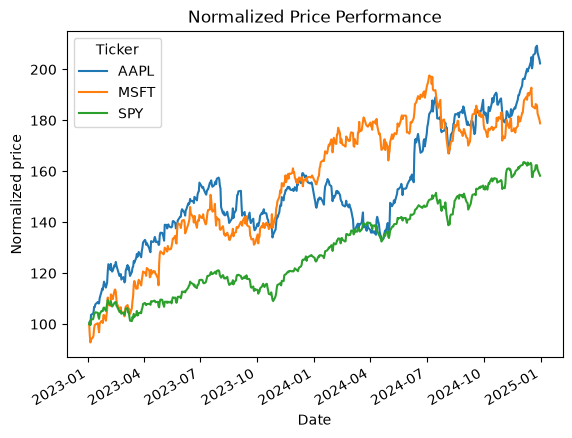

In [21]:
normalized_prices = close_prices / close_prices.iloc[0] * 100
display(normalized_prices.head())

print(
    "All series start from 100:",
    np.allclose(normalized_prices.iloc[0], 100)
)

normalized_prices.plot(
    title="Normalized Price Performance"
)

plt.ylabel("Normalized price")
plt.xlabel("Date")
plt.show()

### 1. Why are adjusted prices useful when analyzing historical returns?

Adjusted prices are useful because they account for corporate actions such as stock splits and dividend distributions, making historical price changes more representative of investor returns.

### 2. Why should prices be converted into returns before calculating correlations?

Price levels are generally not directly comparable and may contain trends over time. Returns express proportional changes and therefore provide a more suitable basis for comparing co-movements across different assets.

### 3. Why is the first row of daily returns missing?

The first return is missing because a return requires both a current price and a preceding price. The first observation has no previous trading-day price.

### 4. What is the difference between annualized arithmetic return and actual cumulative return?

The annualized arithmetic return is obtained by multiplying the average daily return by 252. It is a simplified annualization and does not account for compounding.

The cumulative simple return measures the actual compounded change over the observed period and is calculated by multiplying one plus each daily return and subtracting one.

### 5. Why are normalized prices more suitable than raw prices for visual performance comparisons?

Normalized prices place all assets on the same starting value, such as 100. This makes their relative performance directly comparable even when their original price levels are different.

### 6. What limitations should be considered when using data downloaded through an external provider?

Data obtained from an external provider may contain missing observations, revisions, inconsistencies or temporary download failures. The analysis also depends on the provider's definitions and adjustment methodology. For this reason, downloaded data should always be validated before use.